# Monitoring ice velocity on Vega Island, Antarctica, using Sentinel-1 offset tracking

## Author: Moritz Rath

Geoprocessing with Python, Wintersemester 25/26, Geographisches Institut, Humboldt-Universität zu Berlin
Supervisors: Dr. Dirk Pflugmacher, Eduardo Ribeiro Lacerda

Hand-in due: April 15, 2026

**1. Import Packages**

In [1]:
import os
import ee
import geemap
import json
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
import re
from pathlib import Path
from matplotlib import pyplot as plt
from matplotlib.dates import date2num, num2date
from scipy.stats import linregress
from statsmodels.nonparametric.smoothers_lowess import lowess
import statsmodels.api as sm

import FCK_ICE_fun as fun

try:
    ee.Initialize()
except Exception as e:
    ee.Authenticate()
    ee.Initialize()

path = 'C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data'

Import region shapefile for Vega Island

In [2]:
regionSHP = gpd.read_file(os.path.join(path, 'geodata/vega_island.shp'))
regionSHP = regionSHP.to_crs(epsg=4326)
regionSHP = regionSHP.drop(columns=['sourcedate', 'revdate'])
regionJS = regionSHP.to_json()
region = ee.FeatureCollection(json.loads(regionJS))

In [9]:
Map = geemap.Map()
Map.centerObject(region, 10)
Map.addLayer(region, {}, 'Region')
Map.addLayer(lo_fc, {}, 'Glaciers')
#Map.addLayer(glaciermask, {}, 'Glacier Mask')
Map

Map(center=[-63.84266356378092, -57.40258782887183], controls=(WidgetControl(options=['position', 'transparent…

Get data from GEE

In [ ]:
s1 = (ee.ImageCollection('COPERNICUS/S1_GRD') \
      .filterBounds(region) \
      .filterDate('2020-01-01', '2025-01-01') \
      .filter(ee.Filter.eq('instrumentMode', 'IW')) \
      .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')) \
      .filter(ee.Filter.eq('resolution_meters', 10)) \
      .select('HH') \
      .map(lambda img: img.set(
          'acq_date',
          ee.String(ee.String(img.get('system:index')).split('_').get(4)).slice(0, 8)
      )) \
      .sort('acq_date'))

In [ ]:
kwargs = {
    'grid_res': 200,
    'window_size': (256, 256),
    'path_out': 'auto',
    'fmt_out': 'GTIFF',
    'projectDir': 'C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister',
    'q' : True,
}

In [5]:
fun.coregisterS1(s1=s1, region=region, kwargs=kwargs)

Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200104.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200110.tif
Calculating tie point grid (153 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200110.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200116.tif
Calculating tie point grid (128 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200116.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200122.tif
Calculating tie point grid (144 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200122.tif
Generating URL ...
Please 

c:\Users\morit\miniforge3\envs\geopyFinal\Lib\site-packages\arosics\Tie_Point_Grid.py:1167: UserWarning: RANSAC filtering could not be applied because there were too few tie points to fit a model.
  warn('RANSAC filtering could not be applied '


Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200427.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200503.tif
Calculating tie point grid (128 points) using 8 CPU cores...
RANSAC skipped because too less valid tie points have been found.


c:\Users\morit\miniforge3\envs\geopyFinal\Lib\site-packages\arosics\DeShifter.py:167: UserWarning: Only 3 valid tie point(s) could be identified. A local shift correction is therefore not reasonable and could cause artifacts in the output image. The target image is corrected globally with the mean X/Y shift of -0.174/0.121 pixels.
  warnings.warn(f'Only {len(self.GCPList)} valid tie point(s) could be identified. A local shift correction '


Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200503.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20200509.tif
Calculating tie point grid (153 points) using 8 CPU cores...
RANSAC skipped because too less valid tie points have been found.


...

Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221201.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221213.tif
Calculating tie point grid (128 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221213.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221225.tif
Calculating tie point grid (153 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20221225.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20230106.tif
Calculating tie point grid (144 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20230106.tif
Generating URL ...
Please 

c:\Users\morit\miniforge3\envs\geopyFinal\Lib\site-packages\arosics\Tie_Point_Grid.py:1167: UserWarning: RANSAC filtering could not be applied because there were too few tie points to fit a model.
  warn('RANSAC filtering could not be applied '


Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240524.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240605.tif
Calculating tie point grid (144 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240605.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240617.tif
Calculating tie point grid (128 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240617.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240629.tif
Calculating tie point grid (153 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240629.tif
Generating URL ...
Please 

c:\Users\morit\miniforge3\envs\geopyFinal\Lib\site-packages\arosics\DeShifter.py:167: UserWarning: Only 2 valid tie point(s) could be identified. A local shift correction is therefore not reasonable and could cause artifacts in the output image. The target image is corrected globally with the mean X/Y shift of 0.213/0.270 pixels.
  warnings.warn(f'Only {len(self.GCPList)} valid tie point(s) could be identified. A local shift correction '


Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240828.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240909.tif
Calculating tie point grid (144 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240909.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240921.tif
Calculating tie point grid (128 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20240921.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20241003.tif
Calculating tie point grid (153 points) using 8 CPU cores...
Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\AppData\Local\Temp\tmp68f5_a9w\20241003.tif
Generating URL ...
Please 

In [ ]:
demCOL = (ee.ImageCollection("UMN/PGC/REMA/V1/2m")\
          .filterBounds(region))
dem_mosaic = demCOL.reduce(ee.Reducer.min())
dem_mosaic = dem_mosaic.clip(region)

In [11]:
regionEx = ee.FeatureCollection(region).geometry()
regionEx = regionEx.transform('EPSG:4326', maxError=1)
geemap.ee_export_image(dem_mosaic, filename=os.path.join(path, "geodata/dem.tif"), 
                       scale=90, region=regionEx, file_per_band=False)

Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\Documents\Uni\HU\Python\geopy_final\data\geodata\dem.tif


Retrieve the glacier mask maximum extent. We pin movement to this area to exclude movement in bedrock around the glaciers. 

In [10]:
rgi = ee.FeatureCollection("GLIMS/20230607") \
        .filterBounds(region)
gl = rgi.geometry().simplify(maxError=1)
glaciermask = gl.dissolve()
parts = ee.List(glaciermask.geometries())
fc_parts = ee.FeatureCollection(
    parts.map(lambda g:  ee.Feature(ee.Geometry(g)).set("area_m2", ee.Geometry(g).area(1)))
)

me = ee.Feature(fc_parts.sort("area_m2", False).first())
me_fc =ee.FeatureCollection([me])

out_shp = os.path.join(path, "geodata", "glacier_max_extent.shp")
geemap.ee_export_vector(me_fc, filename=out_shp)

Generating URL ...
Please wait ...
Data downloaded to C:\Users\morit\Documents\Uni\HU\Python\geopy_final\data\geodata\glacier_max_extent.shp


In [3]:
gm = gpd.read_file(os.path.join(path, "geodata", "glacier_max_extent.shp"))

# Rename the coregistered Images

In [1]:
path_coregister = r'C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister'
fun.renameTifs(path_coregister, move=False, recursive=True)

NameError: name 'fun' is not defined

Load Tifs

In [4]:
p_coregistered = r'C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/coregister_coregistered'
mean_dir = r"C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/means"
os.makedirs(mean_dir, exist_ok=True)
tif_paths = sorted(Path(p_coregistered).glob("*.tif"))
dates = fun.get_dates(tif_paths)

In [5]:
tifs = [rasterio.open(p) for p in tif_paths]

Single means

In [6]:
try:
    masked_arrays, template = fun.maskTif_loop(tifs, regionSHP, gm, crop=False)
finally:
    for ds in tifs:
        ds.close()

In [7]:
single_abs, single_means = fun.single_mean_abs(masked_arrays, dates, template)

Annual and monthly means

In [6]:
try:
    masked_arrays, template = fun.maskTif_loop(tifs, regionSHP, gm, crop=False)

    annual_means, monthly_means = fun.compute_export_means(
        masked_arrays,
        dates,
        template,
        mean_dir
    )
finally:
    for ds in tifs:
        ds.close()

c:\Users\morit\Documents\Uni\HU\Python\geopy_final\FCK_ICE_fun.py:310: RuntimeWarning: Mean of empty slice
  annual_means = {y: np.nanmean(stack[i], axis=0) for y,i in by_year.items()}
c:\Users\morit\Documents\Uni\HU\Python\geopy_final\FCK_ICE_fun.py:311: RuntimeWarning: Mean of empty slice
  monthly_means = {(y,m): np.nanmean(stack[i], axis=0) for (y,m),i in by_month.items()}


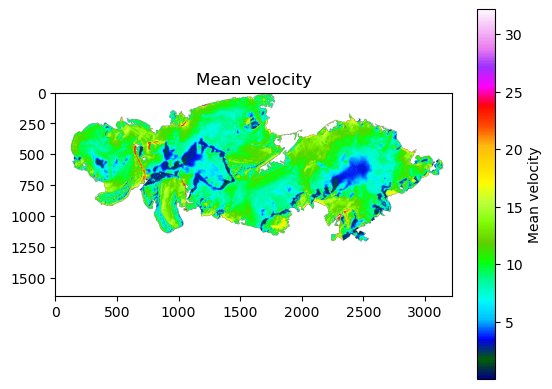

In [24]:
plt.imshow(np.absolute(annual_means[2023]), cmap="gist_ncar")
plt.colorbar(label="Mean velocity")
plt.title("Mean velocity")
plt.show()

# Trend analysis (TSA)

first prepare the data for monthly and annual tsa

In [ ]:
mean_dir = Path("C:/Users/morit/Documents/Uni/HU/Python/geopy_final/data/means")

annual_means = {}
monthly_means = {}

a_pattern = re.compile(r"(\d{4})_mean_ice_velocity\.tif$", re.IGNORECASE)
m_pattern = re.compile(r"(\d{4})_(\d{2})_mean_ice_velocity\.tif$", re.IGNORECASE)

for tif_path in sorted(mean_dir.glob("*.tif")):
    name = tif_path.name

    m_annual = a_pattern.match(name)
    if m_annual:
        y = int(m_annual.group(1))
        with rasterio.open(tif_path) as src:
            annual_means[y] = src.read(1)
        continue

    m_monthly = m_pattern.match(name)
    if m_monthly:
        y = int(m_monthly.group(1))
        m = int(m_monthly.group(2))
        with rasterio.open(tif_path) as src:
            monthly_means[(y, m)] = src.read(1)


In [ ]:
annual_ts = {y: np.nanmean(np.abs(arr)) for y, arr in sorted(annual_means.items())}
monthly_ts = {(y,m): np.nanmean(np.abs(arr)) for (y,m),arr in sorted(monthly_means.items())}

In [5]:
years = np.array(sorted(annual_ts.keys()))
val = np.array([annual_ts[y] for y in years])
x = np.arange(len(years))
slope, intercept, r, _, se = linregress(x, val)
trend = intercept + slope  * x

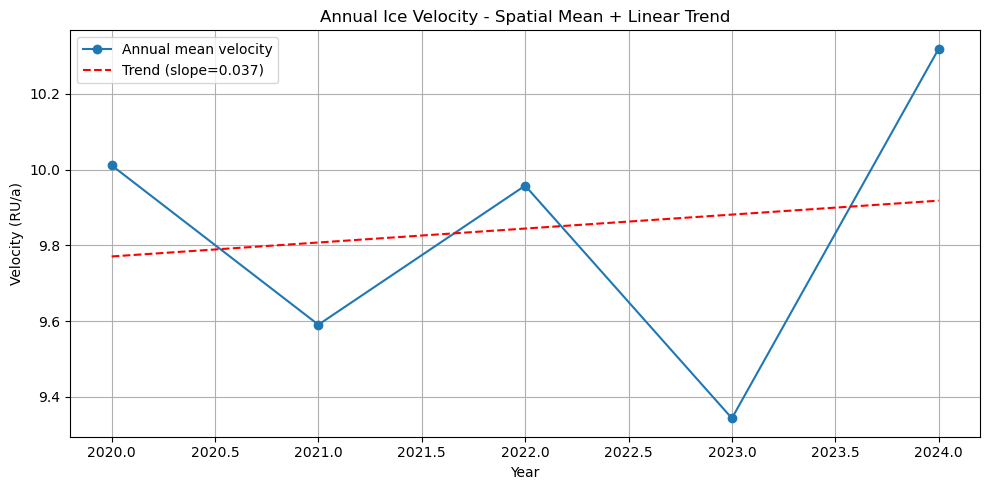

In [ ]:
plt.figure(figsize=(10,5))
plt.plot(years, val, 'o-', label="Annual mean velocity")
plt.plot(years, trend, 'r--', label=f"Trend (slope={slope:.3f})")

plt.xlabel("Year")
plt.ylabel("Velocity (RU/a)")
plt.title("Annual Ice Velocity - Spatial Mean + Linear Trend")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
idx = [pd.to_datetime(f"{y}-{m}-01") for (y,m) in sorted(monthly_means.keys())]
vals = [monthly_ts[(y,m)] for (y,m) in sorted(monthly_means.keys())]
series = pd.Series(vals, index=idx)

In [18]:
decomp = sm.tsa.seasonal_decompose(series, model="additive", period=12)

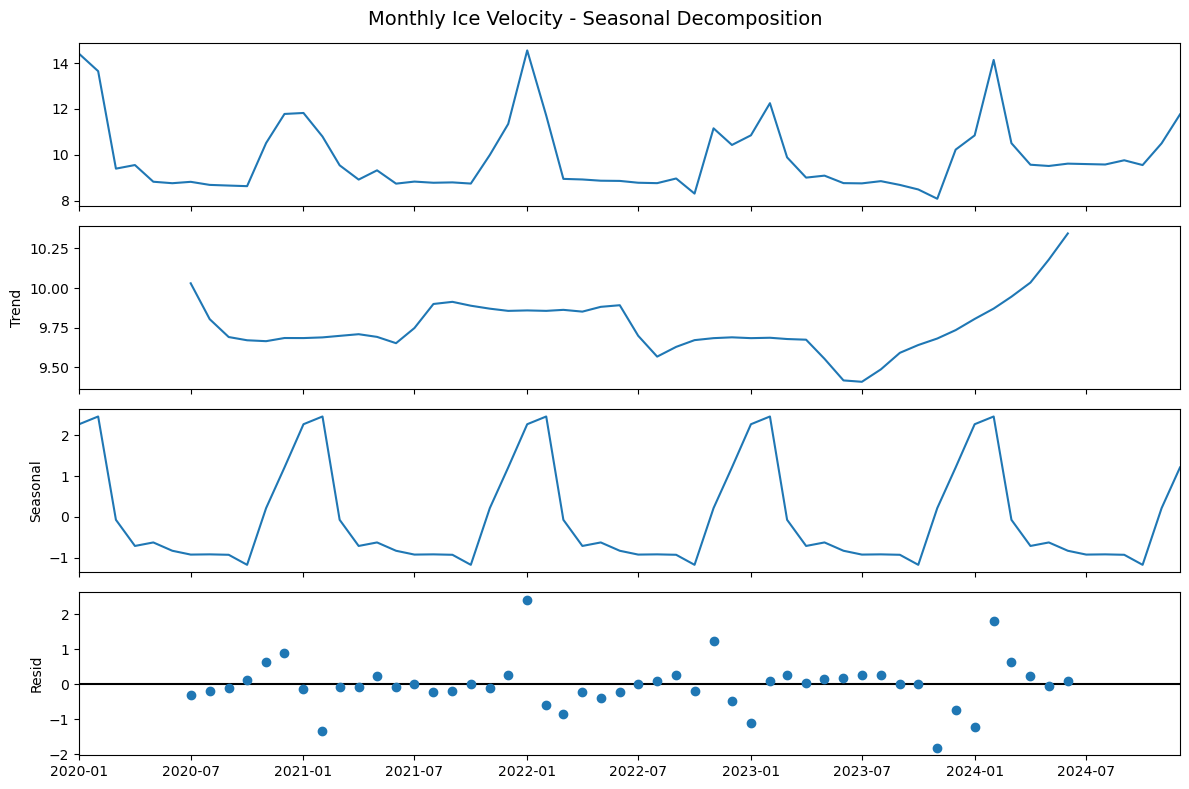

In [20]:
fig = decomp.plot()
fig.set_size_inches(12, 8)
plt.suptitle("Monthly Ice Velocity - Seasonal Decomposition", fontsize=14)
plt.tight_layout()
plt.show()

Now for the single day tsa

In [8]:
idx = [pd.Timestamp(y, m, d) for (y, m, d) in sorted(single_means.keys())]
vals = [single_means[i] for i in sorted(single_means.keys())]
d_series = pd.Series(vals, index = idx).sort_index()

In [15]:
s = d_series.sort_index().dropna()
if not isinstance(s.index, pd.DatetimeIndex):
    s.index = pd.to_datetime(s.index)

y_daily = np.abs(s.astype(float))

x = date2num(y_daily.index.to_pydatetime())
y = y_daily.values

frac=.2
low = lowess(y, x, frac=frac, return_sorted=True)
x_fit = low[:, 0]
y_fit = low[:, 1]

y_fit_at_obs = np.interp(x, x_fit, y_fit)
resid = y- y_fit_at_obs

ts_15 = y_daily.resample("15D").median()

rng = np.random.default_rng(42)
n_boot = 300
boot_preds = np.empty((n_boot, len(x_fit)), dtype=float)

for i in range(n_boot):
    idx = rng.integers(0, len(x), len(x))
    xb = x[idx]
    yb = y[idx]

    order = np.argsort(xb)
    xb = xb[order]
    yb = yb[order]

    low_b = lowess(yb, xb, frac=frac, return_sorted=True)


    xu, iu = np.unique(low_b[:, 0], return_index=True)
    yu = low_b[iu, 1]
    boot_preds[i, :] = np.interp(x_fit, xu, yu)

lower = np.nanpercentile(boot_preds, 2.5, axis=0)
upper = np.nanpercentile(boot_preds, 97.5, axis=0)

In [26]:
s = d_series.dropna().sort_index()
if not isinstance(s.index, pd.DatetimeIndex):
    s.index = pd.to_datetime(s.index)

y = s.values.astype(float)
t = (s.index - s.index.min()).days.values.astype(float)
doy = s.index.dayofyear.values.astype(float)

X = pd.DataFrame({"t": t})
K = 2
for k in range(1, K+1):
    X[f"sin{k}"] = np.sin(2 * np.pi * k *doy / 365.25)
    X[f"cos{k}"] = np.cos(2 * np.pi * k * doy /365.25)

X = sm.add_constant(X)
model = sm.OLS(y,X).fit()
yhat = model.predict(X)

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.577
Model:                            OLS   Adj. R-squared:                  0.567
Method:                 Least Squares   F-statistic:                     55.13
Date:                Tue, 14 Apr 2026   Prob (F-statistic):           6.15e-36
Time:                        14:48:35   Log-Likelihood:                -322.50
No. Observations:                 208   AIC:                             657.0
Df Residuals:                     202   BIC:                             677.0
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          9.9264      0.142     69.963      0.0

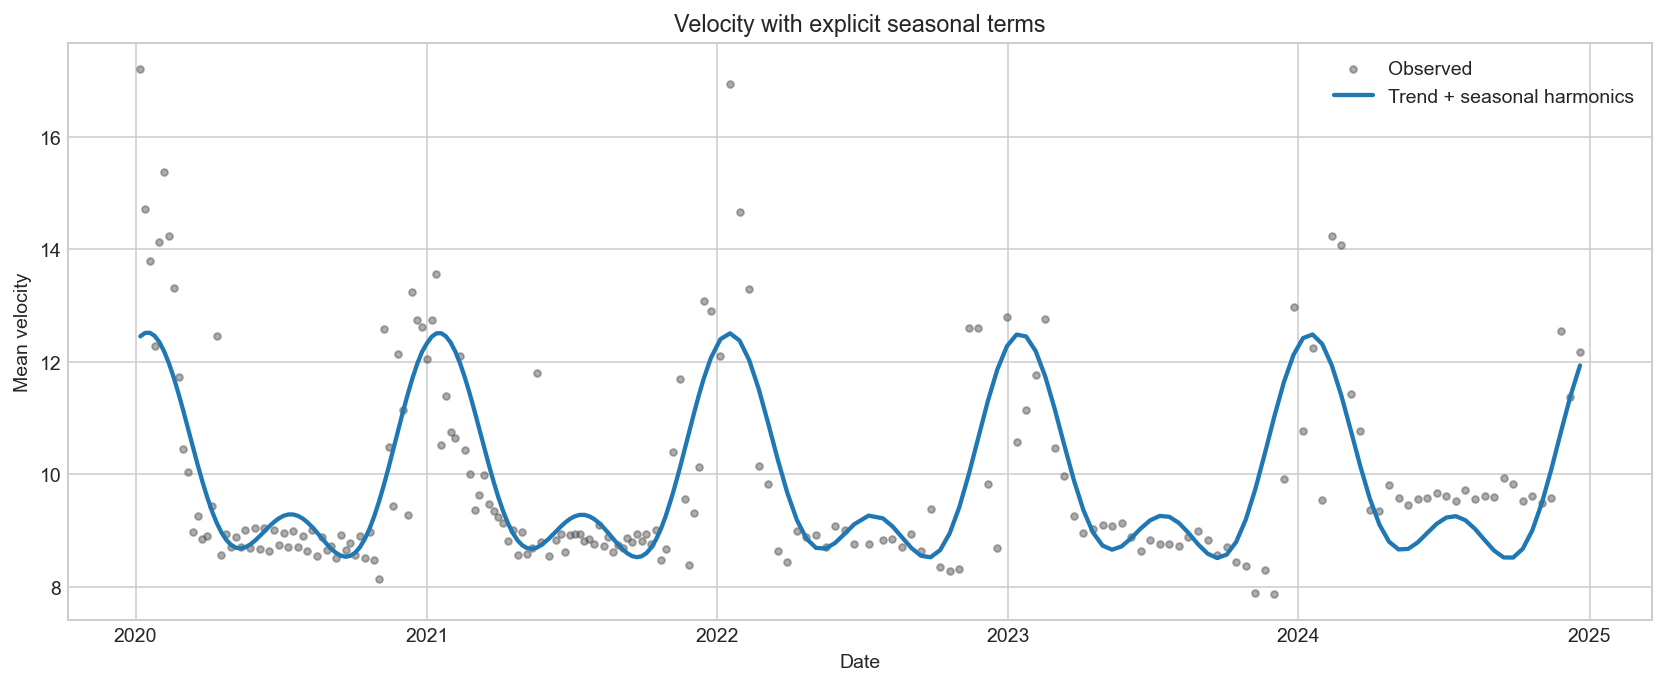

In [27]:
plt.figure(figsize=(12, 5), dpi=140)
plt.scatter(s.index, y, s=12, alpha=.45, color="0.3", label="Observed")
plt.plot(s.index, yhat, color="#1f77b4", lw=2.2, label="Trend + seasonal harmonics")
plt.legend()
plt.xlabel("Date")
plt.ylabel("Mean velocity")
plt.title("Velocity with explicit seasonal terms")
plt.tight_layout()
plt.show()


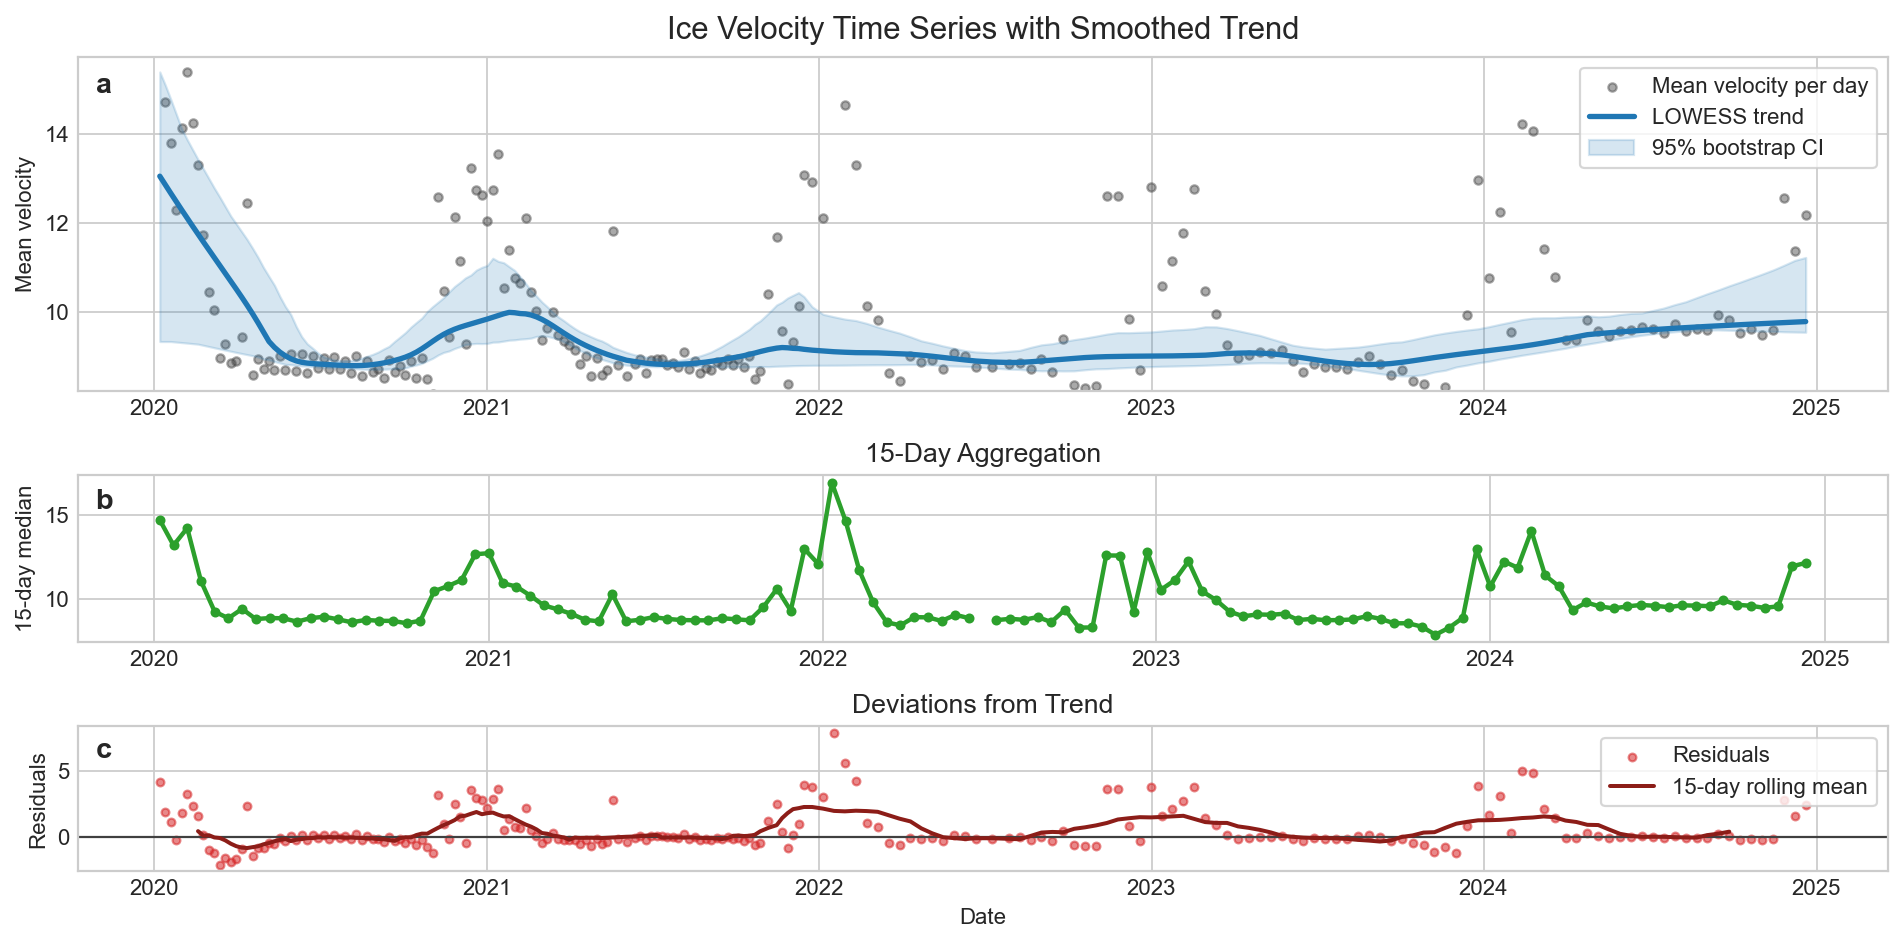

In [18]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(3,1,figsize=(12,6), dpi=160, sharex=False, gridspec_kw={
    "height_ratios": [3, 1.5, 1.3]
})

ax = axes[0]
ax.scatter(y_daily.index, y, s=14, color="0.25", alpha=.45, label="Mean velocity per day")
ax.plot(num2date(x_fit), y_fit, color="#1f77b4", lw=2.4, label="LOWESS trend")
ax.fill_between(num2date(x_fit), lower, upper, color="#1f77b4", alpha=.18, label="95% bootstrap CI")
ax.set_ylabel("Mean velocity")
ax.set_title("Ice Velocity Time Series with Smoothed Trend", fontsize=14, pad=8)
ax.legend(frameon=True, fontsize=10, loc="upper right")
ax.text(.01, .95, "a", transform=ax.transAxes, fontsize=13, fontweight="bold",va="top")

ax = axes[1]
ax.plot(ts_15.index, ts_15.values, color="#2ca02c", lw=2.0, marker="o", markersize=3.5)
ax.set_ylabel("15-day median")
ax.set_title("15-Day Aggregation", fontsize=12, pad=6)
ax.text(0.01, 0.92, "b", transform=ax.transAxes, fontsize=13, fontweight="bold", va="top")

ax = axes[2]
ax.axhline(0, color="0.25", lw=1)
ax.scatter(y_daily.index, resid, s=12, color="#d62728", alpha=.55, label="Residuals")
ax.plot(
    y_daily.index,
    pd.Series(resid, index=y_daily.index).rolling(15, center=True).mean(),
    color="#8c1d18",lw=1.8, label="15-day rolling mean"
)
ax.set_ylabel("Residuals")
ax.set_xlabel("Date")
ax.set_title("Deviations from Trend", fontsize=12, pad=6)
ax.legend(frameon=True, loc="upper right")
ax.text(0.01, 0.92, "c", transform=ax.transAxes, fontsize=13, fontweight="bold", va="top")
fig.tight_layout()
plt.show()